## In this notebook we test procedures for computing derivatives of the reconstruction power spectrum in the wigglesplit approach.

In [2]:
import sys, os
sys.path.append('../MultiFishLSS/')
from headers import *
from twoPoint import *
from twoPointNoise import *
from classy import Class

import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', serif='Computer Modern Roman')

plt.rcParams.update({
    "font.size": 16,        # default text size
    "axes.titlesize": 18,   # title
    "axes.labelsize": 18,   # x and y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

import os
os.environ["PATH"] += os.pathsep + "/usr/local/texlive/2020/bin/x86_64-darwin"

In [3]:
default_cosmo = {
        'output': 'tCl lCl mPk',
        'non linear':'halofit',
        'l_max_scalars': 4000,
        'lensing': 'yes',
        'A_s': 2.10732e-9,
        'n_s': 0.96824,
        'alpha_s': 0.,
        'h': 0.6770,
        'N_ur': 1.0196,
        'N_ncdm': 2,
        'm_ncdm': '0.01,0.05',
        'tau_reio': 0.0568,
        'omega_b': 0.02247,
        'omega_cdm': 0.11923,
        'Omega_k': 0.,
        'P_k_max_h/Mpc': 2.,
        'z_pk': '0.0,6'}

cosmo = Class()
cosmo.set(default_cosmo)
cosmo.compute()

In [ ]:
fsky = 0.34

bd = './'
sfb = 'desi2_elg'
file_dir = '../DESI2_scripts/'

zs, bs, ns = np.loadtxt(file_dir + sfb+".txt").T
zmin = round(0.1*int(ceil(zs[0]*10)),4)
zmax = round(0.1*int(zs[-1]*10),4)
N = round((zmax-zmin)/0.2)+1

zedg = np.linspace(zmin,zmax,N,endpoint=True)
# 2 galaxy samples 
# name, bias, number density as lists
# Interpolate the bias and number density
b = interp1d(zs,bs)
n = interp1d(zs,ns)

# Set up the experiment object.
exp = experiment(zedges=zedg,fsky=fsky,b=b,n=n)

recon = 'wigglesplit'

surveyname = '{}_{}'.format(recon, sfb)

overwrite = False

# May need to turn recon off here and turn it back on later otherwise the fiducial Pk is the Precon?
forecast = fisherForecast(experiment=exp,cosmo=cosmo,name=surveyname,basedir=bd,recon=recon, overwrite=overwrite)    

Initialising fiducial Pk with recon = wigglesplit and self.recon = False
Finished computing fiducial Pk, setting self.recon = wigglesplit
Initialising fiducial Precon with recon = wigglesplit and self.recon = wigglesplit
Finished computing fiducial Precon, setting self.recon = wigglesplit


### First pass, using $dP/d\mathrm{AP} = C(k,\mu)\partial_{\mathrm{AP}}(P_\mathrm{w}(k',\mu'))$.

In [ ]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap_justwiggle_novolume = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

self.recon == wigglesplit, numerically differentiating Precon with respect to alpha_par/perp


In [68]:
print(dPdap_justwiggle_novolume)

[-0.10403348 -0.1073734  -0.1174359  ... -0.0003983  -0.00055035
 -0.0007112 ]


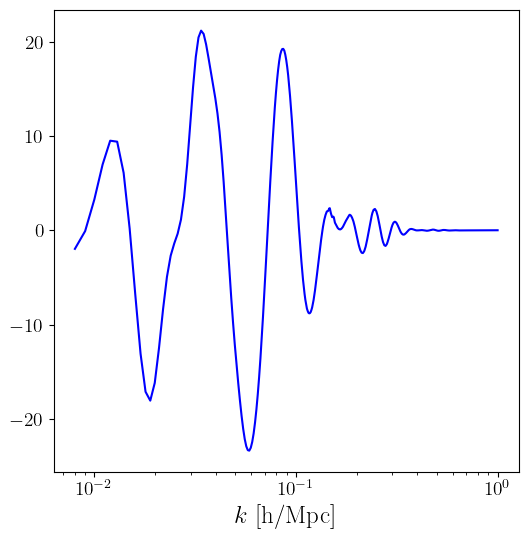

In [69]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,forecast.get_f_at_fixed_mu(dPdap_justwiggle_novolume,0.)(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

### Second pass, using $dP/d\mathrm{AP} = \partial_{\mathrm{AP}}(B(k,\mu)P_\mathrm{nw}(k,\mu) + C(k',\mu')P_\mathrm{w}(k',\mu') + D(k,\mu))$.

In [ ]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

self.recon == wigglesplit, numerically differentiating Precon with respect to alpha_par/perp


In [15]:
print(dPdap)

[-0.13448621 -0.13670478 -0.14340855 ... -0.00098948 -0.00137191
 -0.00177694]


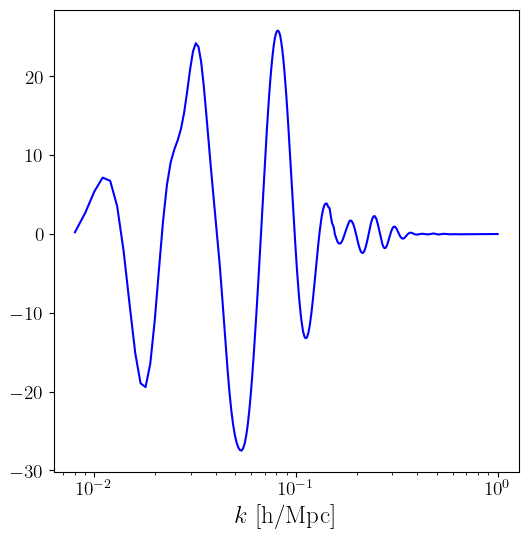

In [16]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,forecast.get_f_at_fixed_mu(dPdap,0.)(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

### Third pass, using $dP/d\mathrm{AP} = \partial_{\mathrm{AP}}(C(k',\mu')P_\mathrm{w}(k',\mu'))$. Should be identical to second pass.

In [ ]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap_ckmupwkmu = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

self.recon == wigglesplit, numerically differentiating Precon with respect to alpha_par/perp


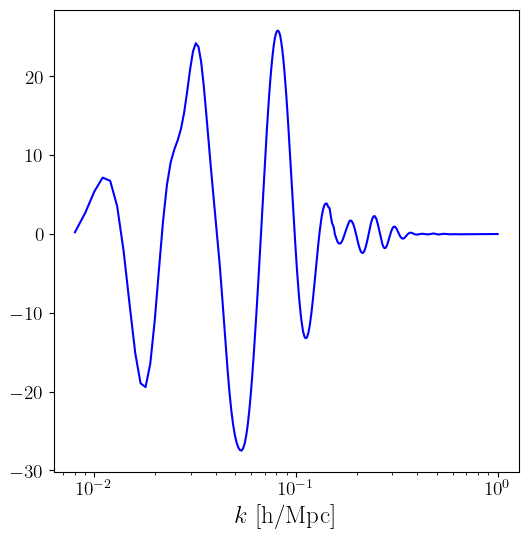

In [114]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,forecast.get_f_at_fixed_mu(dPdap_ckmupwkmu,0.)(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

### Fourth pass, using $dP/d\mathrm{AP} = C(k,\mu)\partial_{\mathrm{AP}}(\alpha_\|^{-1}\alpha_\perp^{-2}P_\mathrm{w}(k',\mu'))$ numerically.

In [ ]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

self.recon == wigglesplit, numerically differentiating Precon with respect to alpha_par/perp
1.01 1.0
1.02 1.0
0.99 1.0
0.98 1.0
1.0 1.0


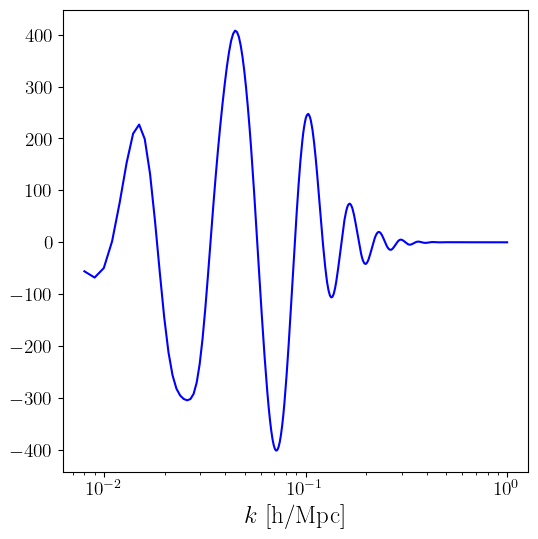

In [25]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,forecast.get_f_at_fixed_mu(dPdap,0.)(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

### Fifth pass, using $dP/d\mathrm{AP} = C(k,\mu)\partial_{\mathrm{AP}}(P_\mathrm{w}(k',\mu')) - C(k,\mu)P_\mathrm{w}(k,\mu)$, i.e. $\alpha_\|$ derivative with volume term done analytially.

In [ ]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap_volumeanalytic = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

self.recon == wigglesplit, numerically differentiating Precon with respect to alpha_par/perp


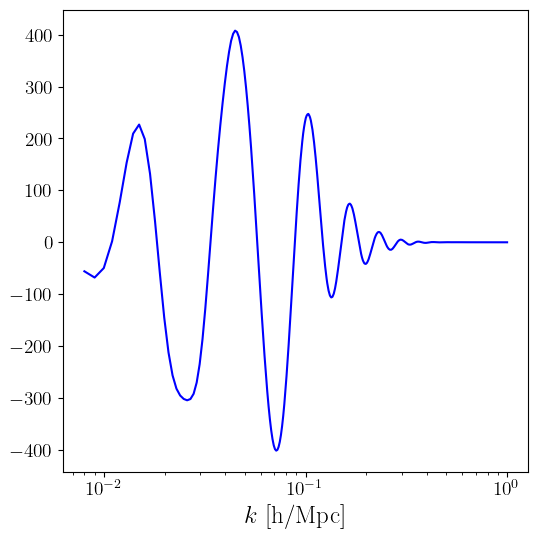

In [60]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,forecast.get_f_at_fixed_mu(dPdap_volumeanalytic,0.)(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

### Sixth pass, using $dP/d\mathrm{AP} = \partial_{\mathrm{AP}}( \alpha_\|^{-1}\alpha_\perp^{-2}C(k',\mu')P_\mathrm{w}(k',\mu'))$ analytically using the method currently employed for LPT.

In [ ]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap_lptmethod = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

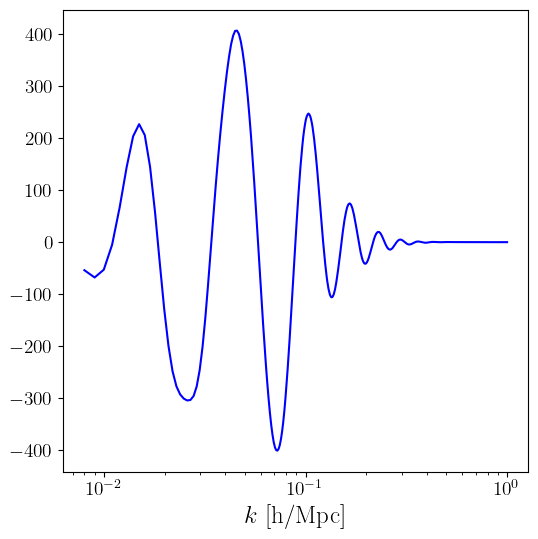

In [42]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,forecast.get_f_at_fixed_mu(dPdap_lptmethod,0.)(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

### Seventh pass, using $dP/d\mathrm{AP} = \partial_{\mathrm{AP}}( \alpha_\|^{-1}\alpha_\perp^{-2}(B(k,\mu)P_\mathrm{nw}(k,\mu) + C(k',\mu')P_\mathrm{w}(k',\mu') + D(k,\mu)))$ analytically using the method currently employed for LPT.

In [ ]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap_fullbroadband = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

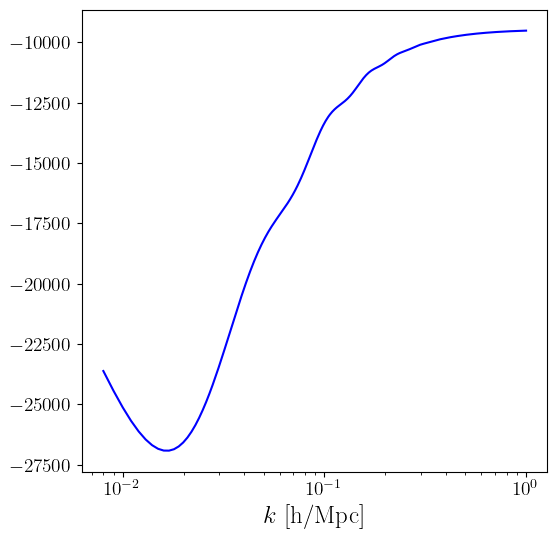

In [46]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,forecast.get_f_at_fixed_mu(dPdap_fullbroadband,0.)(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

## The analytic volume and LPT method derivatives look similar but give vastly different results in the forecast. Compare below.

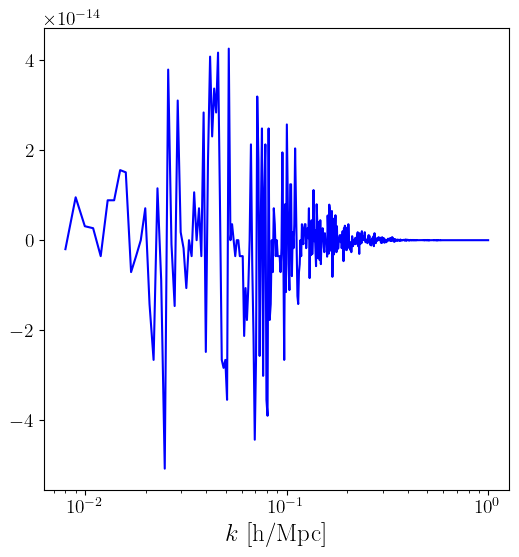

In [ ]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)

dPdap_lptmethod_mu0 = forecast.get_f_at_fixed_mu(dPdap_lptmethod,0.)
dPdap_volumeanalyticmu0 = forecast.get_f_at_fixed_mu(dPdap_volumeanalytic,0.)

dPdap_lpt_volume_diff = dPdap_volumeanalyticmu0(k)-dPdap_lptmethod_mu0(k)

dPdap_justwiggle_novolumemu0 = forecast.get_f_at_fixed_mu(dPdap_justwiggle_novolume,0.)(k)

plt.semilogx(k,dPdap_lpt_volume_diff - dPdap_justwiggle_novolumemu0,color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

In [89]:
K,MU = forecast.k,forecast.mu
h = forecast.cosmo.h()

klin = np.logspace(np.log10(min(K)),np.log10(max(K)),forecast.Nk)
   
mulin = MU.reshape((forecast.Nk,forecast.Nmu))[0,:]

plin = np.array([forecast.cosmo.pk_cb_lin(k*h,z)*h**3. for k in klin])

ckmu_pkmu = compute_tracer_power_spectrum(forecast,Xind=0, Yind=0, z=z, a_perp=1., a_par=1., wiggle=True)

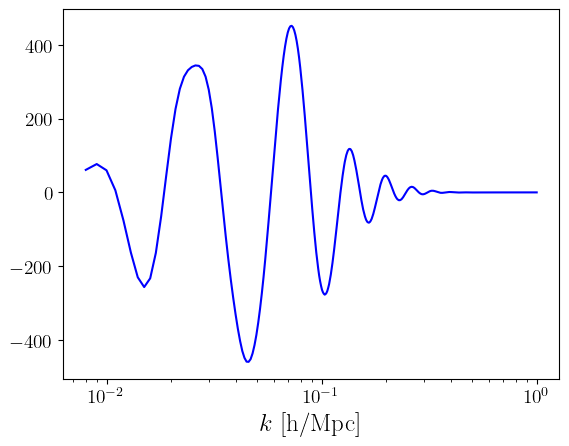

In [104]:
ckmu_pkmumu0 = forecast.get_f_at_fixed_mu(ckmu_pkmu,0.3)

plt.semilogx(k,ckmu_pkmumu0(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

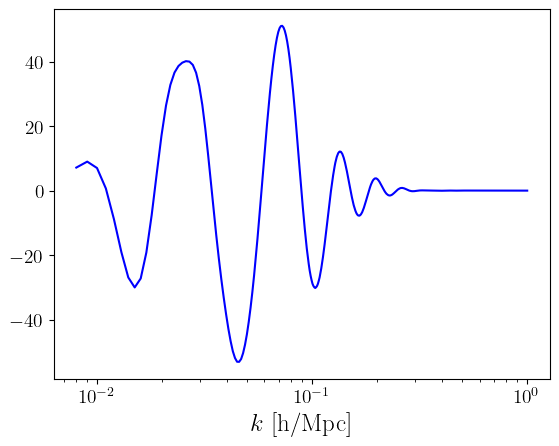

In [91]:
plt.semilogx(k,dPdap_lptmethod_mu0(k) + ckmu_pkmumu0(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

## Edited LPT deriv method so that P_fid = P_wiggle and added compute_C method to dPdp so I compute CdP_w/dmu etc. instead of d/dmu(CP_w).

In [ ]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap_modifiedlpt = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

here


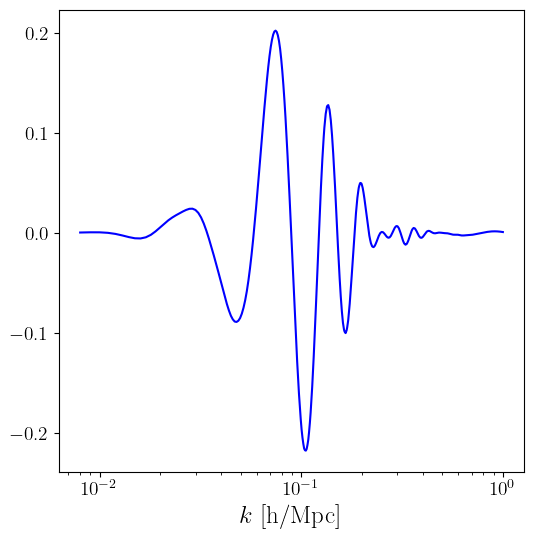

In [101]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)

dPdap_modifiedlptmu0 = forecast.get_f_at_fixed_mu(dPdap_modifiedlpt,0.)

plt.semilogx(k,dPdap_lptmethod_mu0(k)-dPdap_modifiedlptmu0(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

## Eighth pass where I include C(k,mu) in numerical deriv and analytially add volume term.

In [150]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap_full_volumeanalytic = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

self.recon == wigglesplit, numerically differentiating Precon with respect to alpha_par/perp


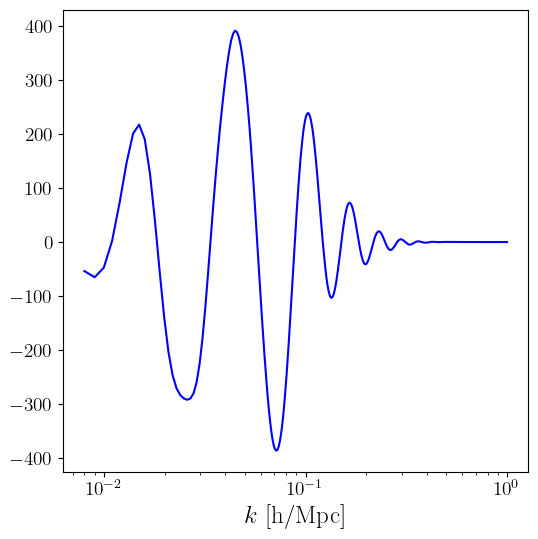

In [151]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,forecast.get_f_at_fixed_mu(dPdap_full_volumeanalytic,0.)(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

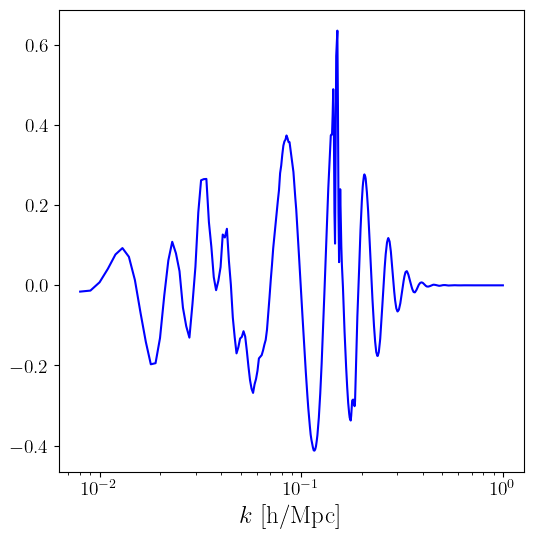

In [152]:
dPdap_full_volumeanalyticmu0 = forecast.get_f_at_fixed_mu(dPdap_full_volumeanalytic,0.)

plt.figure(figsize=(6,6))
plt.semilogx(k,dPdap_full_volumeanalyticmu0(k)-dPdap_lptmethod_mu0(k) -forecast.get_f_at_fixed_mu(dPdap_ckmupwkmu,0.)(k) ,color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

## Ninth pass where I do $dP/d\mathrm{AP} = \partial_{\mathrm{AP}}(\alpha_\|^{-1}\alpha_\perp^{-2}C(k',\mu')P_\mathrm{w}(k',\mu'))$ numerically.

In [153]:
%reload_ext autoreload
%autoreload 2

z = forecast.experiment.zcenters[0]
X=0
Y=0

dPdap_full_numerical = forecast.compute_dPdp('alpha_parallel', X=X, Y=Y, z=z, five_point=True)

self.recon == wigglesplit, numerically differentiating Precon with respect to alpha_par/perp


In [154]:
dPdap_full_numericalmu0 = forecast.get_f_at_fixed_mu(dPdap_full_numerical,0.)

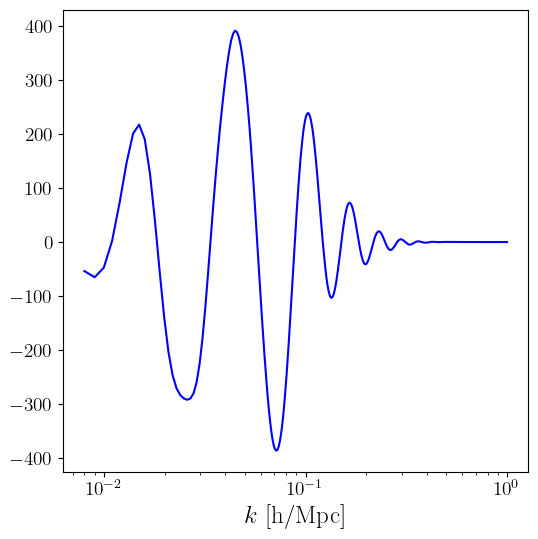

In [155]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,dPdap_full_numericalmu0(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

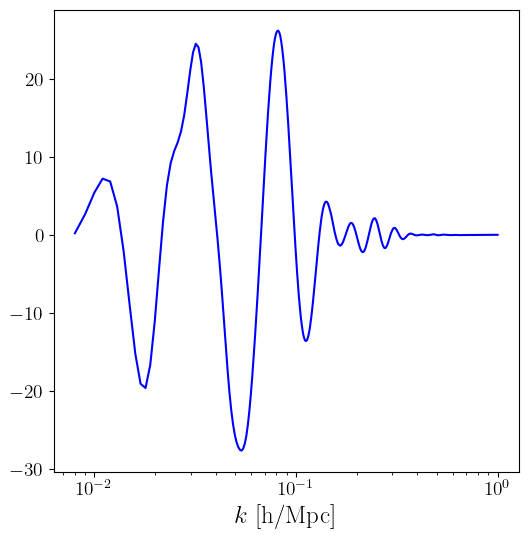

In [ ]:
plt.figure(figsize=(6,6))
k = np.linspace(0.008,1.,1000)
plt.semilogx(k,dPdap_full_numericalmu0(k) - dPdap_full_volumeanalyticmu0(k),color='b')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

In [183]:
%reload_ext autoreload
%autoreload 2

K,MU = forecast.k,forecast.mu
h = forecast.cosmo.h()

klin = np.logspace(np.log10(min(K)),np.log10(max(K)),forecast.Nk)
   
mulin = MU.reshape((forecast.Nk,forecast.Nmu))[0,:]

plin = np.array([forecast.cosmo.pk_cb_lin(k*h,z)*h**3. for k in klin])

Pkmu_multipoles = compute_tracer_power_spectrum(forecast,Xind=0, Yind=0, z=z, a_perp=1., a_par=1., wiggle=True)

In [187]:
%reload_ext autoreload
%autoreload 2

Pkmu_multipoles_diff_interp = compute_tracer_power_spectrum(forecast,Xind=0, Yind=0, z=z, a_perp=1., a_par=1., wiggle=True)

In [195]:
%reload_ext autoreload
%autoreload 2

Pkmu_nomult = compute_tracer_power_spectrum(forecast,Xind=0, Yind=0, z=z, a_perp=1., a_par=1., wiggle=True)

In [196]:
k = np.linspace(0.008,1.,1000)

Pkmu_multipolesmu0 = forecast.get_f_at_fixed_mu(Pkmu_multipoles,0.1)(k)
Pkmu_nomultmu0 = forecast.get_f_at_fixed_mu(Pkmu_nomult,0.1)(k)
Pkmu_multipoles_diff_interpmu0 = forecast.get_f_at_fixed_mu(Pkmu_multipoles_diff_interp,0.1)(k)


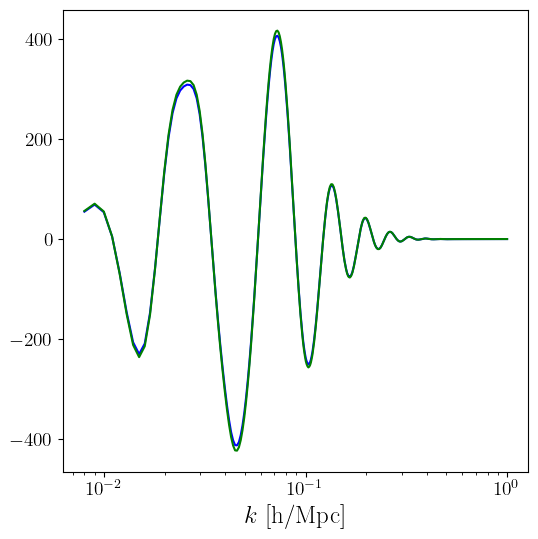

In [197]:
plt.figure(figsize=(6,6))
plt.semilogx(k,Pkmu_multipolesmu0,color='b')
#plt.semilogx(k,Pkmu_multipoles_diff_interpmu0,color='g')

plt.semilogx(k,Pkmu_nomultmu0,color='g')
plt.xlabel(r'$k$ [h/Mpc]')
plt.show()

In [ ]:
print(Pkmu_nomult.shape)

In [ ]:
Pkmu_simps = compute_tracer_power_spectrum(forecast,Xind=0, Yind=0, z=z)

(1, 500)
(50, 1)
pkmu shape (50, 500)
using simpson integration
(50,)
(500, 50)
(50,)
(50,)
(500, 50)
(50,)
(50,)
(500, 50)
(50,)


In [ ]:
%reload_ext autoreload
%autoreload 2

Pkmu_leggauss = compute_tracer_power_spectrum(forecast,Xind=0, Yind=0, z=z)

setting leggauss weights
(1, 500)
(50, 1)
pkmu shape (50, 500)


In [208]:
k = np.linspace(0.008,1.,1000)

Pkmu_simpsmu03 = forecast.get_f_at_fixed_mu(Pkmu_simps,0.3)(k)
Pkmu_leggauss03 = forecast.get_f_at_fixed_mu(Pkmu_leggauss,0.3)(k)


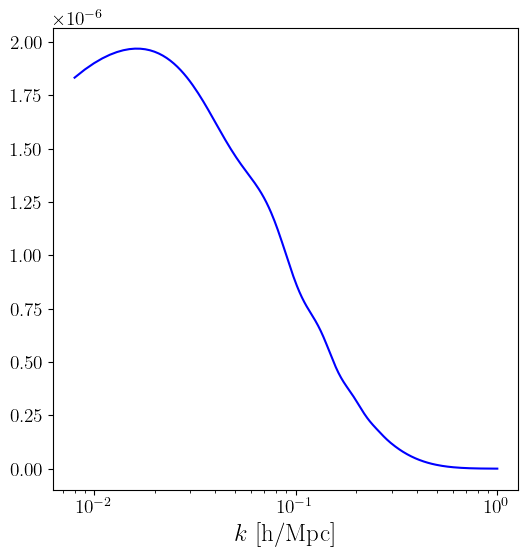

In [211]:
plt.figure(figsize=(6,6))
plt.semilogx(k,(Pkmu_simpsmu03-Pkmu_leggauss03)/Pkmu_simpsmu03,color='b')

plt.xlabel(r'$k$ [h/Mpc]')
plt.show()